# IMP on a Colab GPU

Run the cells in order. In VS Code, select a **Colab GPU** kernel before starting.

In [1]:
import torch

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
assert torch.cuda.is_available(), "Select a Colab GPU kernel before continuing."

2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## Locate the uploaded project

The VS Code extension uploaded the contents of `project/` directly into `/content`, not `/content/project`.

In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path("/content")
required = [PROJECT_ROOT / name for name in ("configs", "scripts", "src", "tests")]
missing = [str(path) for path in required if not path.exists()]
assert not missing, f"Missing uploaded project directories: {missing}"
os.chdir(PROJECT_ROOT)
print("Working directory:", Path.cwd())

Working directory: /content


## Make dense checkpoints available at the configured path

The uploaded `multi_seed` directory is linked to the location expected by the YAML. No checkpoint is copied.

In [3]:
actual = Path("/content/multi_seed")
expected = Path("/content/outputs/sanity_check/multi_seed")
assert actual.is_dir(), f"Dense checkpoint directory not found: {actual}"
expected.parent.mkdir(parents=True, exist_ok=True)
if expected.is_symlink() and expected.resolve() != actual:
    expected.unlink()
if not expected.exists():
    expected.symlink_to(actual, target_is_directory=True)
print("Checkpoint path:", expected, "->", expected.resolve())
for seed in (42, 45, 46):
    seed_dir = expected / f"seed_{seed}"
    assert (seed_dir / "training_history.csv").is_file(), seed_dir / "training_history.csv"
    assert (seed_dir / "epoch_states/epoch_00.pt").is_file(), seed_dir / "epoch_states/epoch_00.pt"
print("Dense inputs for seeds 42, 45, and 46 are ready.")

Checkpoint path: /content/outputs/sanity_check/multi_seed -> /content/multi_seed
Dense inputs for seeds 42, 45, and 46 are ready.


## Validate the uploaded code

In [4]:
!pip -q install matplotlib Pillow PyYAML pytest
!PYTHONPATH=. pytest -q

................                                                         [100%]
16 passed in 2.94s


## Mount Google Drive

With the VS Code Colab extension, use **Ctrl+Shift+P → Colab: Mount Google Drive to Server...**. Complete authentication, then run the verification cell below. Do not use `drive.mount()` here: credential propagation returned HTTP 400 in this VS Code session.

In [5]:
DRIVE_ROOT = Path("/content/drive/MyDrive")
assert DRIVE_ROOT.is_dir(), (
    "Google Drive is not mounted. Run 'Colab: Mount Google Drive to Server...' "
    "from the VS Code command palette, then retry this cell."
)
OUTPUT_ROOT = DRIVE_ROOT / "pruning-shortcuts"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print("Persistent output directory:", OUTPUT_ROOT)

Persistent output directory: /content/drive/MyDrive/pruning-shortcuts


## Smoke test

This runs one seed, two IMP rounds, and two epochs per round. Completed rounds resume automatically.

In [6]:
import subprocess
import time

smoke_output = OUTPUT_ROOT / "imp_smoke_test"
start = time.perf_counter()
subprocess.run([
    "python", "scripts/run_imp.py",
    "--config", "configs/sanity_check.yaml",
    "--smoke-test",
    "--output-dir", str(smoke_output),
], check=True)
smoke_minutes = (time.perf_counter() - start) / 60
print(f"Smoke test completed in {smoke_minutes:.2f} minutes")
print("Summary:", smoke_output / "round_summary.csv")

Smoke test completed in 0.99 minutes
Summary: /content/drive/MyDrive/pruning-shortcuts/imp_smoke_test/round_summary.csv


In [7]:
import pandas as pd

display(pd.read_csv(smoke_output / "round_summary.csv"))

,seed,round,sparsity,shortcut_acquisition_epoch,escape_epoch,shortcut_phase_duration,shortcut_auc,final_epoch,final_overall_accuracy,final_conflicting_accuracy,final_worst_group_accuracy,final_shortcut_gap,final_color_swap_sensitivity,final_shape_swap_sensitivity
0,42,1,0.20,1,NaN,2,2.0,2,0.5,0.0,0.0,1.0,0.892831,0.005141
1,42,2,0.36,1,NaN,2,2.0,2,0.5,0.0,0.0,1.0,0.893502,0.005275


## Full IMP run

Run this cell only after the smoke test succeeds. It executes 3 seeds × 10 rounds. Re-running the cell resumes completed rounds.

In [9]:
imp_output = OUTPUT_ROOT / "imp"
start = time.perf_counter()
subprocess.run([
    "python", "scripts/run_imp.py",
    "--config", "configs/sanity_check.yaml",
    "--output-dir", str(imp_output),
], check=True)
print(f"Full IMP completed in {(time.perf_counter() - start) / 60:.2f} minutes")
print("Summary:", imp_output / "round_summary.csv")

Full IMP completed in 107.78 minutes
Summary: /content/drive/MyDrive/pruning-shortcuts/imp/round_summary.csv


In [10]:
import pandas as pd
from pathlib import Path

summary_path = Path(
    "/content/drive/MyDrive/pruning-shortcuts/imp/round_summary.csv"
)

summary = pd.read_csv(summary_path)

summary["shortcut_acquisition_epoch"] = (
    summary["shortcut_acquisition_epoch"].astype("Int64")
)
summary["escape_epoch"] = summary["escape_epoch"].astype("Int64")

display(summary)

,seed,round,sparsity,shortcut_acquisition_epoch,escape_epoch,shortcut_phase_duration,shortcut_auc,final_epoch,final_overall_accuracy,final_conflicting_accuracy,final_worst_group_accuracy,final_shortcut_gap,final_color_swap_sensitivity,final_shape_swap_sensitivity
0,42,1,0.200000,1,23,17,20.0985,30,0.99825,0.9965,0.993,0.0035,0.019493,0.979618
1,42,2,0.360000,1,22,17,19.5520,30,0.99825,0.9965,0.993,0.0035,0.012534,0.986854
2,42,3,0.488012,1,21,17,18.5215,30,0.99725,0.9945,0.989,0.0055,0.013259,0.986548
3,42,4,0.590409,1,22,16,18.6625,30,0.99675,0.9935,0.987,0.0065,0.012539,0.987569
4,42,5,0.672339,1,21,15,17.7425,30,0.99725,0.9945,0.989,0.0055,0.012693,0.987576
5,42,6,0.737865,1,18,13,15.4580,30,0.99850,0.9970,0.994,0.0030,0.009359,0.990859
6,42,7,0.790292,1,13,9,10.8680,30,0.99875,0.9975,0.995,0.0025,0.008379,0.991956
7,42,8,0.832222,1,12,9,10.1300,30,0.99850,0.9970,0.994,0.0030,0.009076,0.991151
8,42,9,0.865789,1,14,10,11.6460,30,0.99800,0.9960,0.992,0.0040,0.011206,0.989123
9,42,10,0.892632,1,21,11,16.6335,30,0.99425,0.9885,0.977,0.0115,0.020549,0.978978


In [11]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

display(summary)

,seed,round,sparsity,shortcut_acquisition_epoch,escape_epoch,shortcut_phase_duration,shortcut_auc,final_epoch,final_overall_accuracy,final_conflicting_accuracy,final_worst_group_accuracy,final_shortcut_gap,final_color_swap_sensitivity,final_shape_swap_sensitivity
0,42,1,0.200000,1,23,17,20.0985,30,0.99825,0.9965,0.993,0.0035,0.019493,0.979618
1,42,2,0.360000,1,22,17,19.5520,30,0.99825,0.9965,0.993,0.0035,0.012534,0.986854
2,42,3,0.488012,1,21,17,18.5215,30,0.99725,0.9945,0.989,0.0055,0.013259,0.986548
3,42,4,0.590409,1,22,16,18.6625,30,0.99675,0.9935,0.987,0.0065,0.012539,0.987569
4,42,5,0.672339,1,21,15,17.7425,30,0.99725,0.9945,0.989,0.0055,0.012693,0.987576
5,42,6,0.737865,1,18,13,15.4580,30,0.99850,0.9970,0.994,0.0030,0.009359,0.990859
6,42,7,0.790292,1,13,9,10.8680,30,0.99875,0.9975,0.995,0.0025,0.008379,0.991956
7,42,8,0.832222,1,12,9,10.1300,30,0.99850,0.9970,0.994,0.0030,0.009076,0.991151
8,42,9,0.865789,1,14,10,11.6460,30,0.99800,0.9960,0.992,0.0040,0.011206,0.989123
9,42,10,0.892632,1,21,11,16.6335,30,0.99425,0.9885,0.977,0.0115,0.020549,0.978978


In [12]:
metrics = [
    "escape_epoch",
    "shortcut_phase_duration",
    "shortcut_auc",
    "final_overall_accuracy",
    "final_conflicting_accuracy",
    "final_worst_group_accuracy",
    "final_shortcut_gap",
    "final_color_swap_sensitivity",
    "final_shape_swap_sensitivity",
]

aggregate = (
    summary
    .groupby(["round", "sparsity"])[metrics]
    .agg(["mean", "std"])
    .reset_index()
)

display(aggregate)

round  sparsity escape_epoch           shortcut_phase_duration           shortcut_auc           final_overall_accuracy           final_conflicting_accuracy           final_worst_group_accuracy  \
                          mean       std                    mean       std         mean       std                   mean       std                       mean       std                       mean   
0     1  0.200000         18.0   7.81025               14.000000  6.082763    15.779500  6.962512               0.998667  0.001181                   0.997333  0.002363                   0.994667   
1     2  0.360000    16.666667  8.386497               12.000000  6.244998    14.235167  7.331925               0.999000  0.000901                   0.998000  0.001803                   0.996000   
2     3  0.488012         16.0  8.660254               13.333333  7.234178    14.054833  7.815000               0.998167  0.001588                   0.996333  0.003175                   0.992667   
3     4  0.590409         18.0  6.928203               12.666667  4.163332    15.028000  5.410933               0.997833  0.001665                   0.995667  0.003329                   0.991333   
4     5  0.672339         16.0       7.0               11.666667  4.932883    13.694333  5.949015               0.998167  0.001588                   0.996333  0.003175                   0.992667   
5     6  0.737865    14.666667  6.658328               10.000000  4.358899    12.361667  5.689533               0.998500  0.001250                   0.997000  0.002500                   0.994000   
6     7  0.790292         15.0  6.244998               10.333333  3.214550    12.535167  4.941864               0.998333  0.001665                   0.996667  0.003329                   0.993333   
7     8  0.832222    14.666667  8.326664                9.666667  4.041452    12.054833  6.486116               0.998167  0.002021                   0.996333  0.004041                   0.992667   
8     9  0.865789         14.0       7.0                8.333333  2.886751    11.087167  4.963899               0.998250  0.001639                   0.996500  0.003279                   0.993000   
9    10  0.892632    16.666667  6.658328               10.000000  3.605551    13.538667  5.435057               0.996833  0.002626                   0.993667  0.005252                   0.987333   

            final_shortcut_gap           final_color_swap_sensitivity           final_shape_swap_sensitivity            
        std               mean       std                         mean       std                         mean       std  
0  0.004726           0.002667  0.002363                     0.012745  0.009055                     0.986753  0.009302  
1  0.003606           0.002000  0.001803                     0.009519  0.005993                     0.990251  0.005901  
2  0.006351           0.003667  0.003175                     0.009403  0.006777                     0.990393  0.006712  
3  0.006658           0.004333  0.003329                     0.010708  0.006543                     0.989135  0.006270  
4  0.006351           0.003667  0.003175                     0.010143  0.006522                     0.989856  0.006199  
5  0.005000           0.003000  0.002500                     0.008783  0.005543                     0.991222  0.005232  
6  0.006658           0.003333  0.003329                     0.010671  0.006594                     0.989166  0.006787  
7  0.008083           0.003667  0.004041                     0.011955  0.009731                     0.987678  0.010165  
8  0.006557           0.003500  0.003279                     0.010270  0.004749                     0.989682  0.004647  
9  0.010504           0.006333  0.005252                     0.014307  0.009532                     0.985092  0.009382

In [13]:
compact = (
    summary
    .groupby(["round", "sparsity"])
    .agg(
        seeds=("seed", "count"),
        escaped=("escape_epoch", "count"),
        mean_escape_epoch=("escape_epoch", "mean"),
        mean_shortcut_auc=("shortcut_auc", "mean"),
        mean_conflicting_accuracy=("final_conflicting_accuracy", "mean"),
        mean_worst_group_accuracy=("final_worst_group_accuracy", "mean"),
        mean_final_gap=("final_shortcut_gap", "mean"),
        mean_color_sensitivity=("final_color_swap_sensitivity", "mean"),
        mean_shape_sensitivity=("final_shape_swap_sensitivity", "mean"),
    )
    .reset_index()
)

display(
    compact.style.format({
        "sparsity": "{:.1%}",
        "mean_escape_epoch": "{:.2f}",
        "mean_shortcut_auc": "{:.3f}",
        "mean_conflicting_accuracy": "{:.3f}",
        "mean_worst_group_accuracy": "{:.3f}",
        "mean_final_gap": "{:.3f}",
        "mean_color_sensitivity": "{:.3f}",
        "mean_shape_sensitivity": "{:.3f}",
    })
)

,round,sparsity,seeds,escaped,mean_escape_epoch,mean_shortcut_auc,mean_conflicting_accuracy,mean_worst_group_accuracy,mean_final_gap,mean_color_sensitivity,mean_shape_sensitivity
0,1,20.0%,3,3,18.00,15.780,0.997,0.995,0.003,0.013,0.987
1,2,36.0%,3,3,16.67,14.235,0.998,0.996,0.002,0.010,0.990
2,3,48.8%,3,3,16.00,14.055,0.996,0.993,0.004,0.009,0.990
3,4,59.0%,3,3,18.00,15.028,0.996,0.991,0.004,0.011,0.989
4,5,67.2%,3,3,16.00,13.694,0.996,0.993,0.004,0.010,0.990
5,6,73.8%,3,3,14.67,12.362,0.997,0.994,0.003,0.009,0.991
6,7,79.0%,3,3,15.00,12.535,0.997,0.993,0.003,0.011,0.989
7,8,83.2%,3,3,14.67,12.055,0.996,0.993,0.004,0.012,0.988
8,9,86.6%,3,3,14.00,11.087,0.997,0.993,0.003,0.010,0.990
9,10,89.3%,3,3,16.67,13.539,0.994,0.987,0.006,0.014,0.985


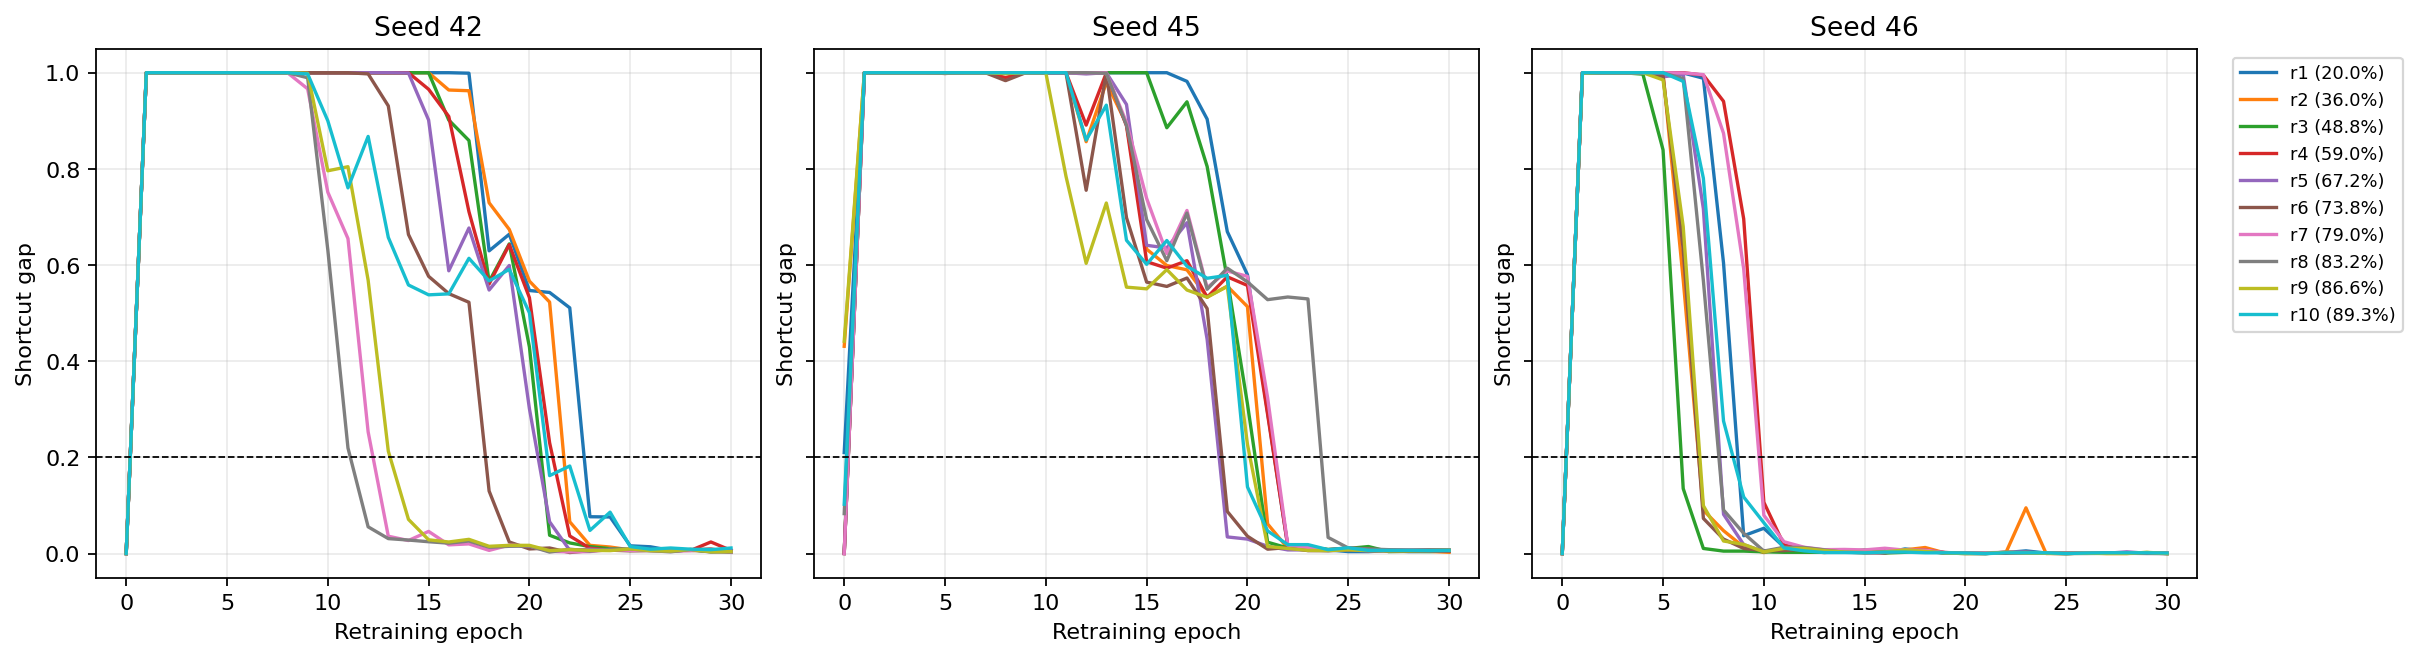

In [14]:
from IPython.display import Image, display

display(Image(
    filename="/content/drive/MyDrive/pruning-shortcuts/imp/imp_shortcut_curves.png"
))

## Extend IMP to 94.5% sparsity

This resumes the existing output directory. Rounds 1–10 are loaded, and only rounds 11–13 are trained, reaching approximately 91.4%, 93.1%, and 94.5% sparsity.

In [ ]:
assert imp_output == Path("/content/drive/MyDrive/pruning-shortcuts/imp")
start = time.perf_counter()
subprocess.run([
    "python", "scripts/run_imp.py",
    "--config", "configs/sanity_check.yaml",
    "--rounds", "13",
    "--output-dir", str(imp_output),
], check=True)
print(f"IMP extension completed in {(time.perf_counter() - start) / 60:.2f} minutes")

## Diagnose the high-sparsity transition

The target signature is: shortcut acquired at epoch 1, no escape within training, and decreasing final shape-swap sensitivity.

In [ ]:
summary = pd.read_csv(imp_output / "round_summary.csv")
summary["shortcut_acquisition_epoch"] = summary["shortcut_acquisition_epoch"].astype("Int64")
summary["escape_epoch"] = summary["escape_epoch"].astype("Int64")
high = summary.query("round >= 10").copy()
high["escaped"] = high["escape_epoch"].notna()
display(high[[
    "seed", "round", "sparsity", "shortcut_acquisition_epoch", "escape_epoch",
    "shortcut_phase_duration", "shortcut_auc", "final_conflicting_accuracy",
    "final_worst_group_accuracy", "final_shortcut_gap",
    "final_color_swap_sensitivity", "final_shape_swap_sensitivity",
]].style.format({
    "sparsity": "{:.1%}",
    "shortcut_auc": "{:.3f}",
    "final_conflicting_accuracy": "{:.3f}",
    "final_worst_group_accuracy": "{:.3f}",
    "final_shortcut_gap": "{:.3f}",
    "final_color_swap_sensitivity": "{:.3f}",
    "final_shape_swap_sensitivity": "{:.3f}",
}))

transition = (
    high.groupby(["round", "sparsity"])
    .agg(
        acquired=("shortcut_acquisition_epoch", "count"),
        escaped=("escaped", "sum"),
        mean_escape_epoch=("escape_epoch", "mean"),
        mean_shortcut_auc=("shortcut_auc", "mean"),
        mean_conflicting_accuracy=("final_conflicting_accuracy", "mean"),
        mean_worst_group_accuracy=("final_worst_group_accuracy", "mean"),
        mean_final_gap=("final_shortcut_gap", "mean"),
        mean_color_sensitivity=("final_color_swap_sensitivity", "mean"),
        mean_shape_sensitivity=("final_shape_swap_sensitivity", "mean"),
    ).reset_index()
)
display(transition.style.format({
    "sparsity": "{:.1%}", "mean_escape_epoch": "{:.2f}",
    "mean_shortcut_auc": "{:.3f}", "mean_conflicting_accuracy": "{:.3f}",
    "mean_worst_group_accuracy": "{:.3f}", "mean_final_gap": "{:.3f}",
    "mean_color_sensitivity": "{:.3f}", "mean_shape_sensitivity": "{:.3f}",
}))

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for seed, rows in summary.groupby("seed"):
    axes[0].plot(rows["sparsity"], rows["escape_epoch"], marker="o", label=f"seed {seed}")
    axes[1].plot(rows["sparsity"], rows["shortcut_auc"], marker="o", label=f"seed {seed}")
    axes[2].plot(rows["sparsity"], rows["final_shape_swap_sensitivity"], marker="o", label=f"seed {seed}")
axes[0].set(title="Escape epoch", xlabel="Sparsity", ylabel="Epoch")
axes[1].set(title="Shortcut AUC", xlabel="Sparsity", ylabel="Sum of gap")
axes[2].set(title="Final shape sensitivity", xlabel="Sparsity", ylabel="Sensitivity", ylim=(-0.02, 1.02))
for ax in axes:
    ax.axvline(0.90, color="black", linestyle="--", linewidth=0.8)
    ax.grid(alpha=0.25)
axes[-1].legend()
plt.show()